# 05 - Final Evaluation and Model Export

This notebook performs the final evaluation and exports the trained machine-learning models for the Smart Learning System.

Core project models:

- Pass/Fail Risk Model
- Sri Lankan A/L Commerce Risk Model

Optional benchmark model:

- xAPI-Edu-Data Performance Model

## 1. Notebook Objectives

This notebook will:

- Load processed datasets from `02_Data_Preprocessing.ipynb`.
- Load best tuning decisions from `04A`, `04B` and `04C` notebooks.
- Rebuild the selected best pipelines.
- Evaluate final models on stratified holdout test sets.
- Fit final export models on the full processed datasets.
- Export `.pkl` model files and feature-column files.
- Export final evaluation summaries for the project report.

In [1]:
from pathlib import Path
import json
import os
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mplconfig")

import joblib
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display as display_image

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)

RANDOM_STATE = 42

## 2. Resolve Project Paths

In [2]:
def find_ml_root(start_path=Path.cwd()):
    current = start_path.resolve()
    for candidate in [current, *current.parents]:
        if candidate.name == "ml-model" and (candidate / "datasets").exists():
            return candidate
        nested = candidate / "ml-model"
        if nested.exists() and (nested / "datasets").exists():
            return nested
    raise FileNotFoundError("Could not locate ml-model directory. Run this notebook inside the project repository.")

ML_ROOT = find_ml_root()
PROCESSED_DIR = ML_ROOT / "datasets" / "processed"
MODELS_DIR = ML_ROOT / "datasets" / "models"
REPORTS_DIR = ML_ROOT / "outputs" / "reports"
FIGURES_DIR = ML_ROOT / "outputs" / "figures"
TUNING_DIR = ML_ROOT / "outputs" / "tuning"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TUNING_DIR.mkdir(parents=True, exist_ok=True)

PASS_FAIL_DATASET = PROCESSED_DIR / "pass_fail_processed.csv"
COMMERCE_RISK_DATASET = PROCESSED_DIR / "commerce_risk_dataset.csv"
XAPI_DATASET = PROCESSED_DIR / "xapi_encoded.csv"
METADATA_PATH = PROCESSED_DIR / "preprocessing_metadata.json"

print("ML root:", ML_ROOT)
print("Models export directory:", MODELS_DIR)
print("Reports directory:", REPORTS_DIR)
print("Figures directory:", FIGURES_DIR)

ML root: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model
Models export directory: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/models
Reports directory: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports
Figures directory: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures


## 3. Load Preprocessing and Tuning Metadata

In [3]:
def load_json(path, required=True):
    path = Path(path)
    if not path.exists():
        if required:
            raise FileNotFoundError(f"Missing JSON file: {path}")
        return {}
    return json.loads(path.read_text())

preprocessing_metadata = load_json(METADATA_PATH, required=False)
pass_fail_tuning = load_json(TUNING_DIR / "pass_fail_tuning_summary.json")
commerce_tuning = load_json(TUNING_DIR / "commerce_risk_tuning_summary.json")
xapi_tuning = load_json(TUNING_DIR / "xapi_tuning_summary.json")

print("Pass/Fail best tuned model:", pass_fail_tuning["best_tuned_model"])
print("Commerce Risk best tuned model:", commerce_tuning["best_tuned_model"])
print("xAPI best tuned model:", xapi_tuning["best_tuned_model"])

Pass/Fail best tuned model: Random Forest
Commerce Risk best tuned model: Decision Tree
xAPI best tuned model: Random Forest


## 4. Final Model Configuration

The final export uses the best tuned choices from the dedicated tuning notebooks.

In [4]:
pass_fail_features = pass_fail_tuning.get("features") or preprocessing_metadata.get("pass_fail_features")
pass_fail_target = pass_fail_tuning.get("target", "pass")

commerce_features = commerce_tuning.get("features") or [
    "Accounting_Score",
    "Business_Studies_Score",
    "Economics_Score",
    "Attendance_Percentage",
]
commerce_target = commerce_tuning.get("target", "risk_level")
commerce_expected_classes = commerce_tuning.get("expected_classes", ["High Risk", "Medium Risk", "Low Risk"])
commerce_available_classes = commerce_tuning.get("available_classes", [])

xapi_features = preprocessing_metadata.get("xapi_encoded_feature_names", [])
xapi_target = xapi_tuning.get("target", preprocessing_metadata.get("xapi_target", "Class"))
xapi_target_encoding = xapi_tuning.get("target_encoding", preprocessing_metadata.get("xapi_target_encoding", {"L": 0, "M": 1, "H": 2}))
xapi_leakage_columns = xapi_tuning.get("excluded_leakage_columns", ["Class_Encoded"])

print("Pass/Fail features:", pass_fail_features)
print("Commerce features:", commerce_features)
print("xAPI feature count:", len(xapi_features))
print("Commerce available classes:", commerce_available_classes)

Pass/Fail features: ['attendance_pct', 'homework_pct', 'midterm_score', 'study_hours_per_week']
Commerce features: ['Accounting_Score', 'Business_Studies_Score', 'Economics_Score', 'Attendance_Percentage']
xAPI feature count: 72
Commerce available classes: ['Low Risk', 'Medium Risk']


## 5. Data Leakage Prevention

Final export follows the same leakage-prevention rules used in previous notebooks:

- Pipelines contain imputation and scaling, so transformations are fitted only on training data during evaluation.
- Final exported pipelines are fitted on the full processed dataset only after evaluation is complete.
- `Subject_Average` is excluded from the Commerce Risk model.
- `Class_Encoded` is excluded from the xAPI model.
- Feature-column files are exported with the model files to keep inference inputs consistent.

## 6. Load Processed Datasets

In [5]:
def load_dataset(path, name):
    if not path.exists():
        raise FileNotFoundError(f"Missing {name}: {path}")
    df = pd.read_csv(path)
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]} columns")
    return df

pass_fail_df = load_dataset(PASS_FAIL_DATASET, "Pass/Fail Processed Dataset")
commerce_df = load_dataset(COMMERCE_RISK_DATASET, "Commerce Risk Processed Dataset")
xapi_df = load_dataset(XAPI_DATASET, "xAPI Encoded Dataset")

Pass/Fail Processed Dataset: 100 rows x 6 columns
Commerce Risk Processed Dataset: 1,002 rows x 7 columns
xAPI Encoded Dataset: 478 rows x 74 columns


## 7. Validate Feature and Target Columns

In [6]:
if not xapi_features:
    xapi_features = [column for column in xapi_df.columns if column not in [xapi_target, *xapi_leakage_columns]]

# Explicitly remove leakage columns even if metadata changes later.
xapi_features = [column for column in xapi_features if column not in xapi_leakage_columns and column != xapi_target]

validation_config = {
    "Pass/Fail Risk": (pass_fail_df, pass_fail_features, pass_fail_target),
    "Commerce Risk": (commerce_df, commerce_features, commerce_target),
    "xAPI Benchmark": (xapi_df, xapi_features, xapi_target),
}

for task_name, (df, features, target) in validation_config.items():
    missing = [column for column in features + [target] if column not in df.columns]
    if missing:
        raise ValueError(f"{task_name} missing required columns: {missing}")
    print(f"{task_name}: {len(features)} features, target={target}")

print("Commerce leakage columns excluded:", commerce_tuning.get("excluded_leakage_columns", ["Subject_Average"]))
print("xAPI leakage columns excluded:", xapi_leakage_columns)

Pass/Fail Risk: 4 features, target=pass
Commerce Risk: 4 features, target=risk_level
xAPI Benchmark: 72 features, target=Class
Commerce leakage columns excluded: ['Subject_Average']
xAPI leakage columns excluded: ['Class_Encoded']


## 8. Helper Functions

In [7]:
def strip_model_prefix(params):
    return {key.replace("model__", ""): value for key, value in params.items()}


def build_pipeline(model_name, best_params, task_type):
    model_params = strip_model_prefix(best_params)

    if model_name == "Logistic Regression":
        model = LogisticRegression(
            max_iter=1500,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            **model_params,
        )
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", model),
        ])

    if model_name == "Decision Tree":
        model = DecisionTreeClassifier(
            random_state=RANDOM_STATE,
            class_weight="balanced",
            **model_params,
        )
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", model),
        ])

    if model_name == "Random Forest":
        model = RandomForestClassifier(
            random_state=RANDOM_STATE,
            class_weight="balanced",
            **model_params,
        )
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", model),
        ])

    raise ValueError(f"Unsupported model name: {model_name}")


def calculate_metrics(y_true, y_pred, task_type):
    if task_type == "binary":
        return {
            "Accuracy": accuracy_score(y_true, y_pred),
            "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1 Score": f1_score(y_true, y_pred, zero_division=0),
            "Macro F1 Score": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "Weighted F1 Score": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        }

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1 Score": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1 Score": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


def evaluate_final_model(task_name, df, features, target, model_name, best_params, task_type, labels):
    X = df[features].copy()
    y = df[target].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    evaluation_pipeline = build_pipeline(model_name, best_params, task_type)
    evaluation_pipeline.fit(X_train, y_train)
    predictions = evaluation_pipeline.predict(X_test)

    metrics = calculate_metrics(y_test, predictions, task_type)

    min_class_count = int(y.value_counts().min())
    cv_splits = min(5, min_class_count)
    if cv_splits >= 2:
        scoring = {
            "accuracy": "accuracy",
            "balanced_accuracy": "balanced_accuracy",
            "macro_f1": "f1_macro",
            "weighted_f1": "f1_weighted",
        }
        cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)
        cv_pipeline = build_pipeline(model_name, best_params, task_type)
        cv_scores = cross_validate(cv_pipeline, X, y, cv=cv, scoring=scoring)
        metrics.update({
            "CV Accuracy": cv_scores["test_accuracy"].mean(),
            "CV Balanced Accuracy": cv_scores["test_balanced_accuracy"].mean(),
            "CV Macro F1 Score": cv_scores["test_macro_f1"].mean(),
            "CV Weighted F1 Score": cv_scores["test_weighted_f1"].mean(),
            "CV Folds": cv_splits,
        })

    return evaluation_pipeline, predictions, X_train, X_test, y_train, y_test, metrics


def save_confusion_matrix(y_true, y_pred, labels, title, output_path):
    matrix = confusion_matrix(y_true, y_pred, labels=labels)
    display_obj = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
    fig, ax = plt.subplots(figsize=(7, 6))
    display_obj.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(title)
    plt.xticks(rotation=20)
    plt.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    print("Saved:", output_path)
    display_image(Image(filename=str(output_path)))

## 9. Build Final Candidate Pipelines

In [8]:
final_tasks = {
    "Pass/Fail Risk": {
        "df": pass_fail_df,
        "features": pass_fail_features,
        "target": pass_fail_target,
        "task_type": "binary",
        "labels": [0, 1],
        "model_name": pass_fail_tuning["best_tuned_model"],
        "best_params": pass_fail_tuning["best_parameters"],
        "core_project_model": True,
        "export_model_file": "pass_fail_model.pkl",
        "export_features_file": "pass_fail_feature_columns.pkl",
    },
    "Commerce Risk": {
        "df": commerce_df,
        "features": commerce_features,
        "target": commerce_target,
        "task_type": "multiclass",
        "labels": commerce_available_classes or sorted(commerce_df[commerce_target].unique().tolist()),
        "model_name": commerce_tuning["best_tuned_model"],
        "best_params": commerce_tuning["best_parameters"],
        "core_project_model": True,
        "export_model_file": "final_risk_model.pkl",
        "export_features_file": "final_feature_columns.pkl",
    },
    "xAPI Benchmark": {
        "df": xapi_df,
        "features": xapi_features,
        "target": xapi_target,
        "task_type": "multiclass",
        "labels": xapi_tuning.get("available_classes", sorted(xapi_df[xapi_target].unique().tolist())),
        "model_name": xapi_tuning["best_tuned_model"],
        "best_params": xapi_tuning["best_parameters"],
        "core_project_model": False,
        "export_model_file": "student_risk_model.pkl",
        "export_features_file": "feature_columns.pkl",
    },
}

for task_name, config in final_tasks.items():
    print(task_name, "->", config["model_name"], config["best_params"])

Pass/Fail Risk -> Random Forest {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Commerce Risk -> Decision Tree {'model__criterion': 'gini', 'model__max_depth': 2, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
xAPI Benchmark -> Random Forest {'model__max_depth': 12, 'model__max_features': 'log2', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 300}


## 10. Final Holdout Evaluation

In [9]:
evaluation_rows = []
evaluation_artifacts = {}

for task_name, config in final_tasks.items():
    print("\n" + "=" * 80)
    print("Evaluating:", task_name)

    evaluation_pipeline, predictions, X_train, X_test, y_train, y_test, metrics = evaluate_final_model(
        task_name=task_name,
        df=config["df"],
        features=config["features"],
        target=config["target"],
        model_name=config["model_name"],
        best_params=config["best_params"],
        task_type=config["task_type"],
        labels=config["labels"],
    )

    evaluation_artifacts[task_name] = {
        "pipeline": evaluation_pipeline,
        "predictions": predictions,
        "X_test": X_test,
        "y_test": y_test,
        "metrics": metrics,
    }

    evaluation_rows.append({
        "Task": task_name,
        "Core Project Model": config["core_project_model"],
        "Final Model": config["model_name"],
        "Rows": int(config["df"].shape[0]),
        "Feature Count": int(len(config["features"])),
        **metrics,
    })

final_evaluation_df = pd.DataFrame(evaluation_rows).round(4)
display(final_evaluation_df)

final_evaluation_path = REPORTS_DIR / "final_model_evaluation_summary.csv"
final_evaluation_df.to_csv(final_evaluation_path, index=False)
print("Saved:", final_evaluation_path)


Evaluating: Pass/Fail Risk

Evaluating: Commerce Risk

Evaluating: xAPI Benchmark


,Task,Core Project Model,Final Model,Rows,Feature Count,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,Macro F1 Score,Weighted F1 Score,CV Accuracy,CV Balanced Accuracy,CV Macro F1 Score,CV Weighted F1 Score,CV Folds,Macro Precision,Macro Recall
0,Pass/Fail Risk,True,Random Forest,100,4,1.0000,1.0000,1.0,1.0,1.0,1.0000,1.0000,1.0000,1.0000,1.0000,1.000,5,NaN,NaN
1,Commerce Risk,True,Decision Tree,1002,4,1.0000,1.0000,NaN,NaN,NaN,1.0000,1.0000,0.9990,0.9833,0.9907,0.999,5,1.0000,1.0000
2,xAPI Benchmark,False,Random Forest,478,72,0.7812,0.7994,NaN,NaN,NaN,0.7881,0.7791,0.7865,0.8008,0.7938,0.785,5,0.7812,0.7994


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/final_model_evaluation_summary.csv


## 11. Classification Reports

In [10]:
classification_report_paths = []

for task_name, config in final_tasks.items():
    artifacts = evaluation_artifacts[task_name]
    y_test = artifacts["y_test"]
    predictions = artifacts["predictions"]

    print("\n" + task_name)
    if config["task_type"] == "binary":
        report_text = classification_report(y_test, predictions, target_names=["Fail", "Pass"], zero_division=0)
        report_dict = classification_report(y_test, predictions, target_names=["Fail", "Pass"], output_dict=True, zero_division=0)
    else:
        report_text = classification_report(y_test, predictions, zero_division=0)
        report_dict = classification_report(y_test, predictions, output_dict=True, zero_division=0)

    print(report_text)
    safe_name = task_name.lower().replace("/", "_").replace(" ", "_")
    report_path = REPORTS_DIR / f"{safe_name}_final_classification_report.json"
    report_path.write_text(json.dumps(report_dict, indent=2))
    classification_report_paths.append(report_path)
    print("Saved:", report_path)


Pass/Fail Risk
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         8
        Pass       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/pass_fail_risk_final_classification_report.json

Commerce Risk
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00       195
 Medium Risk       1.00      1.00      1.00         6

    accuracy                           1.00       201
   macro avg       1.00      1.00      1.00       201
weighted avg       1.00      1.00      1.00       201

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/commerce_risk_final_classification_report.json

xAPI Benchmark
              precision    recall  f1-sc

## 12. Final Confusion Matrices

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/pass_fail_risk_final_confusion_matrix.png


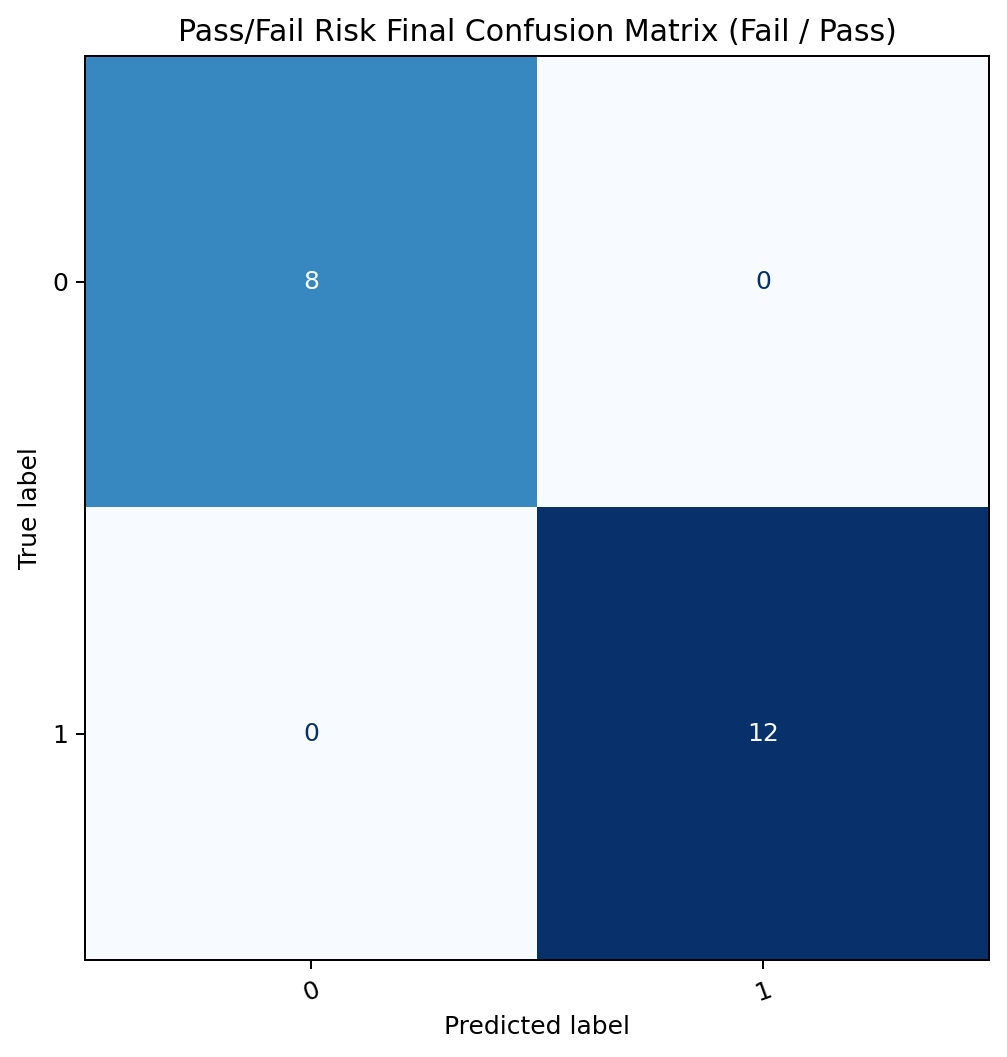

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/commerce_risk_final_confusion_matrix.png


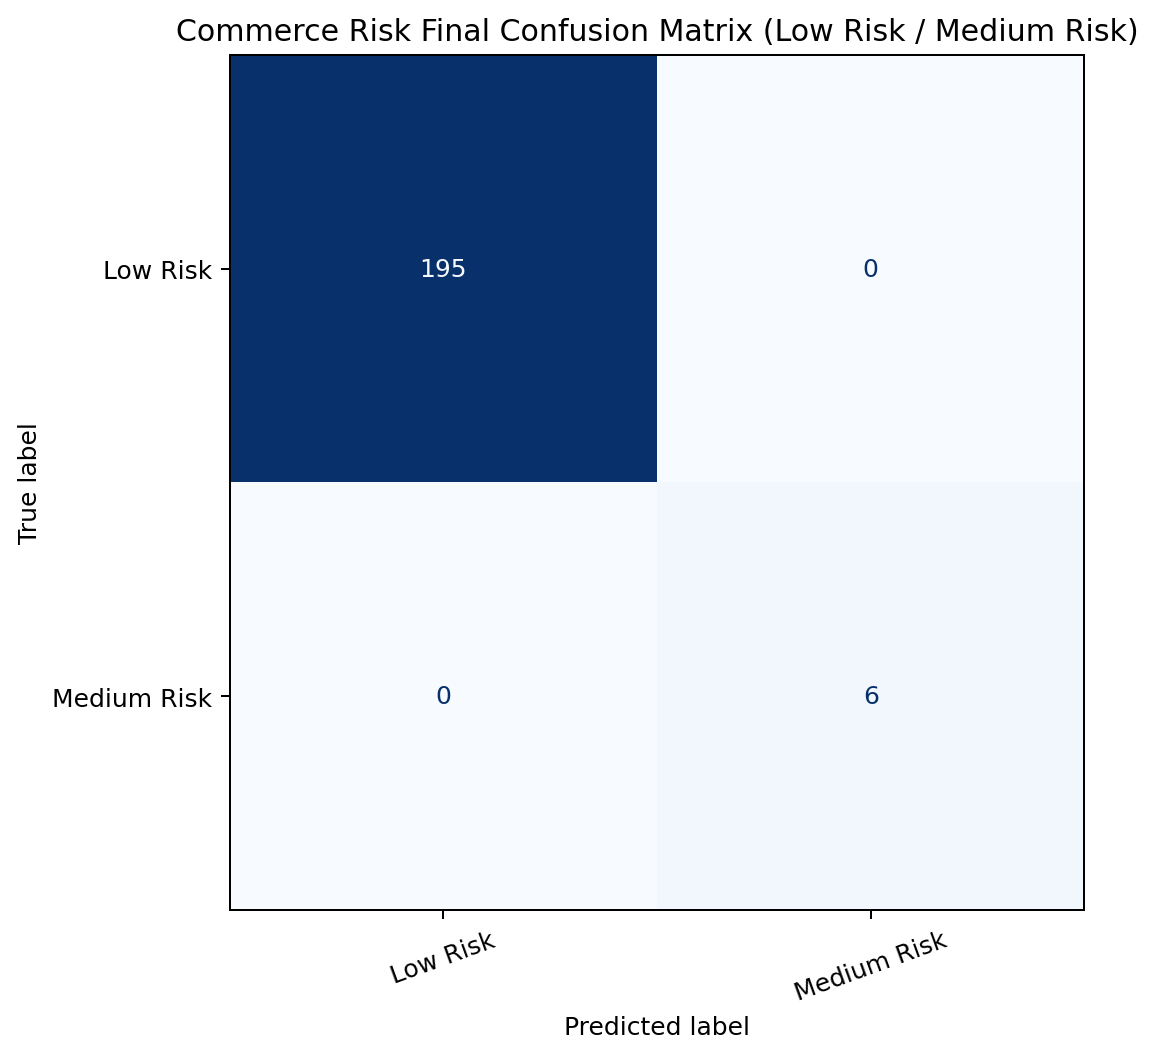

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/xapi_benchmark_final_confusion_matrix.png


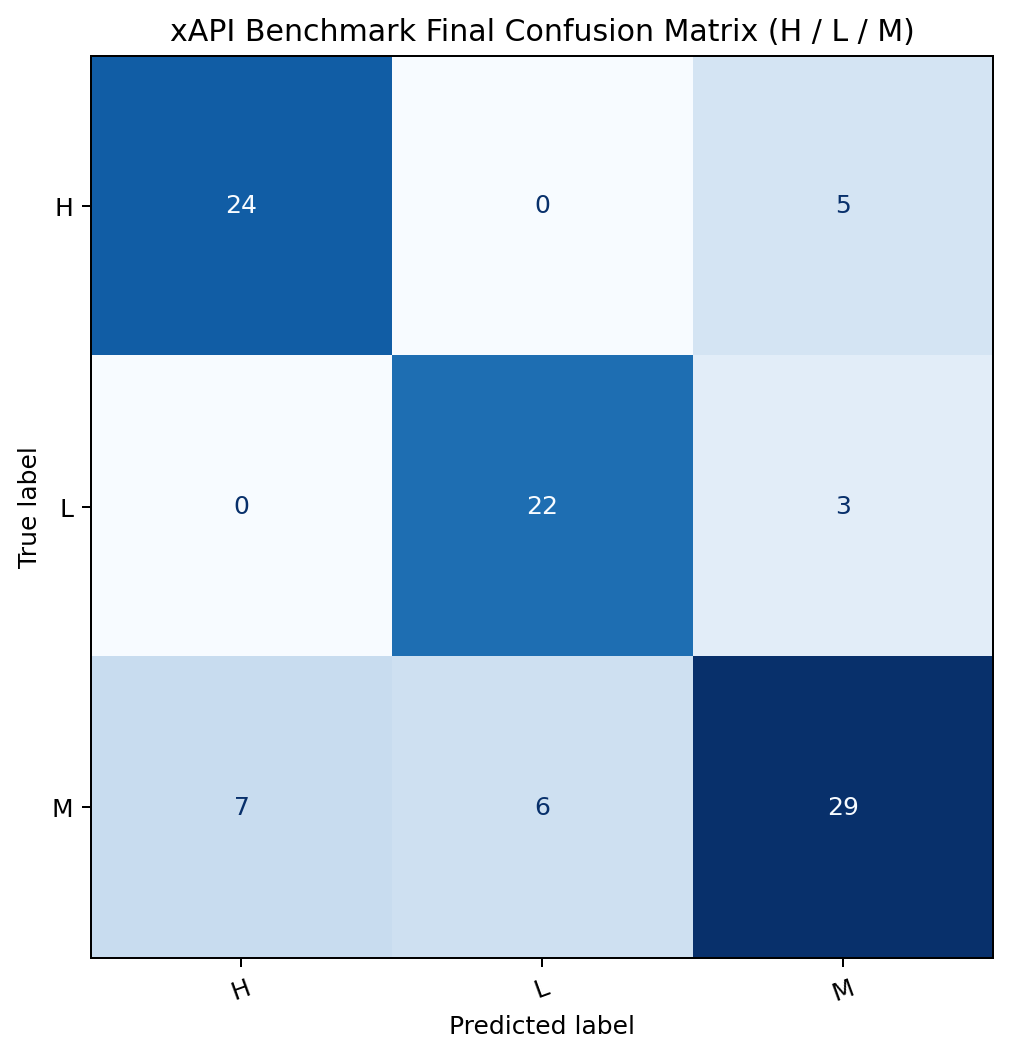

In [11]:
for task_name, config in final_tasks.items():
    artifacts = evaluation_artifacts[task_name]
    labels = config["labels"]
    if config["task_type"] == "binary":
        display_labels = [0, 1]
        title_labels = "Fail / Pass"
    else:
        display_labels = labels
        title_labels = " / ".join(map(str, labels))

    safe_name = task_name.lower().replace("/", "_").replace(" ", "_")
    output_path = FIGURES_DIR / f"{safe_name}_final_confusion_matrix.png"
    save_confusion_matrix(
        artifacts["y_test"],
        artifacts["predictions"],
        display_labels,
        f"{task_name} Final Confusion Matrix ({title_labels})",
        output_path,
    )

## 13. Fit Final Export Models on Full Processed Datasets

After holdout evaluation is complete, the export pipelines are fitted on the full processed datasets so the saved model can use all available training data.

In [12]:
exported_paths = []
final_export_models = {}

for task_name, config in final_tasks.items():
    X_full = config["df"][config["features"]].copy()
    y_full = config["df"][config["target"]].copy()

    final_pipeline = build_pipeline(
        config["model_name"],
        config["best_params"],
        config["task_type"],
    )
    final_pipeline.fit(X_full, y_full)
    final_export_models[task_name] = final_pipeline

    model_path = MODELS_DIR / config["export_model_file"]
    features_path = MODELS_DIR / config["export_features_file"]

    joblib.dump(final_pipeline, model_path)
    joblib.dump(config["features"], features_path)

    exported_paths.extend([model_path, features_path])
    print("Exported model:", model_path)
    print("Exported feature columns:", features_path)

Exported model: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/models/pass_fail_model.pkl
Exported feature columns: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/models/pass_fail_feature_columns.pkl
Exported model: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/models/final_risk_model.pkl
Exported feature columns: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/models/final_feature_columns.pkl
Exported model: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/models/student_risk_model.pkl
Exported feature columns: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/models/feature_columns.pkl


## 14. Export xAPI Encoder / Label Metadata

The xAPI preprocessing stage already produced an encoded dataset. For deployment consistency, this notebook exports the target-label mapping and notes as `encoders.pkl`.

In [13]:
encoder_metadata = {
    "xapi_target": xapi_target,
    "xapi_target_encoding": xapi_target_encoding,
    "excluded_leakage_columns": xapi_leakage_columns,
    "feature_columns_file": "feature_columns.pkl",
    "note": "xAPI categorical variables were already one-hot encoded in 02_Data_Preprocessing.ipynb. This file stores target-label metadata for inference/documentation.",
}

encoders_path = MODELS_DIR / "encoders.pkl"
xapi_feature_columns_path = MODELS_DIR / "xapi_feature_columns.pkl"

joblib.dump(encoder_metadata, encoders_path)
joblib.dump(xapi_features, xapi_feature_columns_path)

exported_paths.extend([encoders_path, xapi_feature_columns_path])
print("Exported:", encoders_path)
print("Exported:", xapi_feature_columns_path)

Exported: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/models/encoders.pkl
Exported: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/models/xapi_feature_columns.pkl


## 15. Export Model Metadata Summary

In [14]:
model_export_metadata = {
    "random_state": RANDOM_STATE,
    "export_directory": str(MODELS_DIR),
    "core_project_models": ["Pass/Fail Risk", "Commerce Risk"],
    "optional_benchmark_model": "xAPI Benchmark",
    "data_leakage_prevention": {
        "pass_fail": "Target pass is excluded from X; preprocessing is inside the pipeline.",
        "commerce_risk": "Subject_Average is excluded from X; preprocessing is inside the pipeline.",
        "xapi": "Class_Encoded is excluded from X; preprocessing is inside the pipeline.",
    },
    "models": {},
}

for task_name, config in final_tasks.items():
    metrics = evaluation_artifacts[task_name]["metrics"]
    model_export_metadata["models"][task_name] = {
        "model_file": config["export_model_file"],
        "feature_columns_file": config["export_features_file"],
        "selected_model": config["model_name"],
        "best_parameters": config["best_params"],
        "target": config["target"],
        "features": config["features"],
        "labels": config["labels"],
        "core_project_model": config["core_project_model"],
        "evaluation_metrics": {key: float(value) for key, value in metrics.items()},
    }

metadata_path = MODELS_DIR / "model_export_metadata.json"
metadata_path.write_text(json.dumps(model_export_metadata, indent=2))
exported_paths.append(metadata_path)
print("Saved:", metadata_path)

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/models/model_export_metadata.json


## 16. Exported Files Checklist

The project originally needs these model artifacts:

- `pass_fail_model.pkl`
- `pass_fail_feature_columns.pkl`
- `final_risk_model.pkl`
- `final_feature_columns.pkl`
- `student_risk_model.pkl`
- `encoders.pkl`
- `feature_columns.pkl`

In [15]:
required_export_files = [
    "pass_fail_model.pkl",
    "pass_fail_feature_columns.pkl",
    "final_risk_model.pkl",
    "final_feature_columns.pkl",
    "student_risk_model.pkl",
    "encoders.pkl",
    "feature_columns.pkl",
    "xapi_feature_columns.pkl",
    "model_export_metadata.json",
]

checklist_rows = []
for file_name in required_export_files:
    path = MODELS_DIR / file_name
    checklist_rows.append({
        "File": file_name,
        "Exists": path.exists(),
        "Size Bytes": path.stat().st_size if path.exists() else 0,
        "Path": str(path),
    })

export_checklist_df = pd.DataFrame(checklist_rows)
display(export_checklist_df)

checklist_path = REPORTS_DIR / "model_export_checklist.csv"
export_checklist_df.to_csv(checklist_path, index=False)
print("Saved:", checklist_path)

,File,Exists,Size Bytes,Path
0,pass_fail_model.pkl,True,69394,/Users/admin/Documents/ICBT/Smart-Learning-Sys...
1,pass_fail_feature_columns.pkl,True,87,/Users/admin/Documents/ICBT/Smart-Learning-Sys...
2,final_risk_model.pkl,True,2643,/Users/admin/Documents/ICBT/Smart-Learning-Sys...
3,final_feature_columns.pkl,True,102,/Users/admin/Documents/ICBT/Smart-Learning-Sys...
4,student_risk_model.pkl,True,4204138,/Users/admin/Documents/ICBT/Smart-Learning-Sys...
5,encoders.pkl,True,339,/Users/admin/Documents/ICBT/Smart-Learning-Sys...
6,feature_columns.pkl,True,1378,/Users/admin/Documents/ICBT/Smart-Learning-Sys...
7,xapi_feature_columns.pkl,True,1378,/Users/admin/Documents/ICBT/Smart-Learning-Sys...
8,model_export_metadata.json,True,5764,/Users/admin/Documents/ICBT/Smart-Learning-Sys...


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/model_export_checklist.csv


## 17. Quick Inference Smoke Test

This verifies that exported models can be loaded and used for prediction with one sample row.

In [16]:
smoke_test_rows = []

for task_name, config in final_tasks.items():
    model_path = MODELS_DIR / config["export_model_file"]
    features_path = MODELS_DIR / config["export_features_file"]

    loaded_model = joblib.load(model_path)
    loaded_features = joblib.load(features_path)

    sample_X = config["df"][loaded_features].head(1)
    prediction = loaded_model.predict(sample_X)[0]

    smoke_test_rows.append({
        "Task": task_name,
        "Model File": config["export_model_file"],
        "Feature Count": len(loaded_features),
        "Sample Prediction": prediction,
    })

smoke_test_df = pd.DataFrame(smoke_test_rows)
display(smoke_test_df)

smoke_test_path = REPORTS_DIR / "model_export_smoke_test.csv"
smoke_test_df.to_csv(smoke_test_path, index=False)
print("Saved:", smoke_test_path)

,Task,Model File,Feature Count,Sample Prediction
0,Pass/Fail Risk,pass_fail_model.pkl,4,1
1,Commerce Risk,final_risk_model.pkl,4,Low Risk
2,xAPI Benchmark,student_risk_model.pkl,72,M


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/model_export_smoke_test.csv


## 18. Final Project Report Summary

In [17]:
report_summary = {
    "final_notebook": "05_Final_Evaluation_Export.ipynb",
    "summary": "Final selected ML models were evaluated, fitted on the full processed datasets and exported as pickle artifacts.",
    "core_models_exported": {
        "Pass/Fail Risk Model": "pass_fail_model.pkl",
        "Commerce Risk Model": "final_risk_model.pkl",
    },
    "optional_benchmark_model_exported": {
        "xAPI Benchmark Model": "student_risk_model.pkl",
    },
    "important_notes": [
        "Commerce Risk currently uses available classes in commerce_risk_dataset.csv. The current dataset may not include High Risk samples.",
        "xAPI is an optional benchmark model and should not be described as the main Sri Lankan A/L Commerce risk model.",
        "Gemini API features such as essay grading and chatbot do not require these pickle models.",
    ],
    "evaluation_summary_file": str(final_evaluation_path),
    "export_checklist_file": str(checklist_path),
    "smoke_test_file": str(smoke_test_path),
}

report_summary_path = REPORTS_DIR / "final_project_ml_summary.json"
report_summary_path.write_text(json.dumps(report_summary, indent=2))
print("Saved:", report_summary_path)

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/final_project_ml_summary.json


## 19. Final Conclusion

This notebook completed the final ML stage for the Smart Learning System. The best tuned models from the dedicated tuning notebooks were rebuilt, evaluated on holdout test sets, and then refitted on the full processed datasets for export.

The core project models exported by this notebook are the Pass/Fail Risk Model and the Sri Lankan A/L Commerce Risk Model. The xAPI model was also exported as an optional benchmark/research model. Feature-column files, encoder metadata, evaluation summaries and smoke-test results were exported to support reliable backend integration and project documentation.